# Regressão Logística

Nos dois notebooks anteriores trabalhamos com **regressão**: o target $y$ era contínuo, usamos a loss L2 e encontramos os parâmetros via OLS analítico (notebook 01) ou via gradiente descendente (notebook 02). Agora vamos atacar **classificação binária**, em que $y \in \{0, 1\}$ codifica duas classes.

A regressão logística é o ponto de partida natural. Ela reaproveita a estrutura linear $\boldsymbol{\theta}^\top \mathbf{x}$, mas a "esmaga" para o intervalo $[0, 1]$ usando a função logística (sigmoid), e troca a loss L2 por uma loss derivada da likelihood Bernoulli (a **log-loss**).

Neste notebook vamos:
1. Ver por que regressão linear direta não serve para classificação;
2. Estudar a função logística e sua inversa (logit / log-odds);
3. Definir o espaço de hipóteses da regressão logística;
4. Derivar a log-loss a partir da likelihood;
5. Implementar a regressão logística *from scratch* usando gradiente descendente;
6. Comparar com `scikit-learn` e `statsmodels`;
7. Visualizar a fronteira de decisão em 2D.

(Conteúdo correspondente aos slides 136--145.)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(42)

---
## 1. Motivação

Queremos um classificador **probabilístico discriminante**: dada uma observação $\mathbf{x}$, modelar diretamente
$$\pi(\mathbf{x} \mid \boldsymbol{\theta}) = p(y = 1 \mid \mathbf{x}, \boldsymbol{\theta}) \in [0, 1].$$

Codificando $y \in \{0, 1\}$, usamos minimização de risco empírico (ERM):
$$\arg\min_{\boldsymbol{\theta} \in \Theta}\; \mathcal{R}_{\text{emp}}(\boldsymbol{\theta}) \;=\; \arg\min_{\boldsymbol{\theta} \in \Theta}\; \sum_{i=1}^{n} L\!\left(y^{(i)},\, \pi(\mathbf{x}^{(i)} \mid \boldsymbol{\theta})\right).$$

Queremos **importar ideias da regressão linear** --- manter a estrutura "principalmente" linear $\boldsymbol{\theta}^\top \mathbf{x}$ --- mas ainda nos faltam duas coisas: (i) uma forma de garantir $\pi(\mathbf{x} \mid \boldsymbol{\theta}) \in [0, 1]$ e (ii) uma loss apropriada para targets binários.

---
## 2. Por que regressão linear direta não serve

Tentar modelar $\pi(\mathbf{x} \mid \boldsymbol{\theta}) = \boldsymbol{\theta}^\top \mathbf{x}$ direto e ajustar com loss L2 produz previsões **fora do intervalo $[0, 1]$** --- elas não são probabilidades válidas. Vamos mostrar isso com um exemplo de uma única feature.

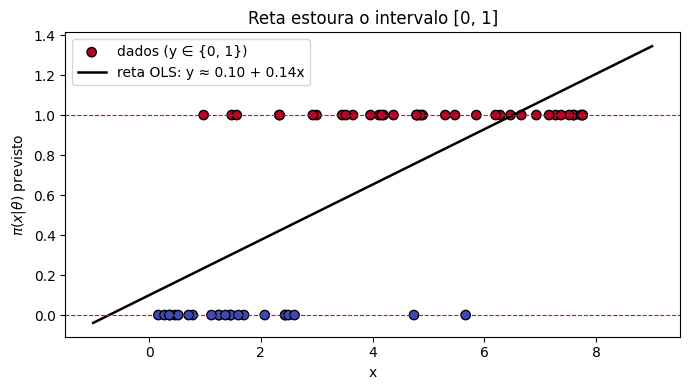

In [3]:
# Dataset de demonstração: uma feature, target binário
n_demo = 60
x_demo = np.random.uniform(0, 8, n_demo)

# Probabilidade verdadeira: sigmoid(-3 + 1.0 * x)
p_true = 1 / (1 + np.exp(-(-3 + 1.0 * x_demo)))
y_demo = (np.random.uniform(size=n_demo) < p_true).astype(int)

# Ajusta uma reta y = a + b*x via mínimos quadrados
X_demo = np.column_stack([np.ones(n_demo), x_demo])
beta_hat = np.linalg.inv(X_demo.T @ X_demo) @ X_demo.T @ y_demo

x_grid = np.linspace(-1, 9, 200)
y_lin = beta_hat[0] + beta_hat[1] * x_grid

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x_demo, y_demo, c=y_demo, cmap='coolwarm',
           edgecolors='black', s=45, label='dados (y ∈ {0, 1})')
ax.plot(x_grid, y_lin, color='black', linewidth=1.8,
        label=f'reta OLS: y ≈ {beta_hat[0]:.2f} + {beta_hat[1]:.2f}x')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.axhline(1, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('x'); ax.set_ylabel(r'$\pi(x|\theta)$ previsto')
ax.set_title('Reta estoura o intervalo [0, 1]')
ax.legend(); plt.tight_layout(); plt.show()

A reta passa por valores negativos para $x$ pequeno e ultrapassa 1 para $x$ grande. Não dá para interpretar essas saídas como probabilidades.

---
## 3. A função logística

Para forçar a saída a ficar em $[0, 1]$, a regressão logística "esmaga" o score linear $f = \boldsymbol{\theta}^\top \mathbf{x}$ pela **função logística** (também chamada **sigmoid**):
$$\pi(\mathbf{x} \mid \boldsymbol{\theta}) = \frac{\exp(\boldsymbol{\theta}^\top \mathbf{x})}{1 + \exp(\boldsymbol{\theta}^\top \mathbf{x})} = \frac{1}{1 + \exp(-\boldsymbol{\theta}^\top \mathbf{x})} = s(\boldsymbol{\theta}^\top \mathbf{x}) = s(f(\mathbf{x})).$$

A sigmoid é monótona crescente, vai de 0 a 1 nos limites, vale exatamente $0{,}5$ quando $f = 0$ e tem inflexão nesse ponto.

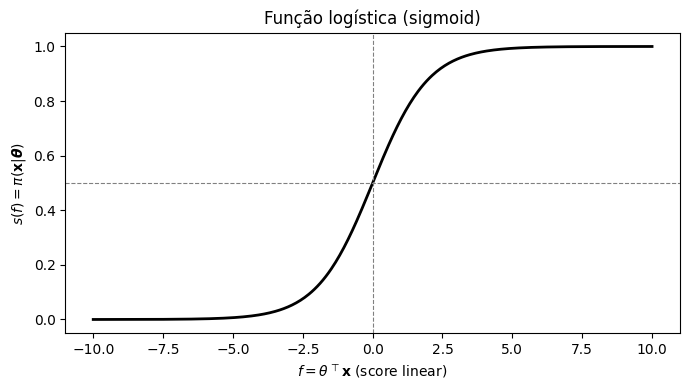

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 400)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, sigmoid(z), color='black', linewidth=2)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel(r'$f = \theta^\top \mathbf{x}$ (score linear)')
ax.set_ylabel(r'$s(f) = \pi(\mathbf{x}|\boldsymbol{\theta})$')
ax.set_title('Função logística (sigmoid)')
plt.tight_layout(); plt.show()

### 3.1 Efeito do intercept $\theta_0$ --- deslocamento horizontal

Quando o score é da forma $f = \theta_0 + \tilde f$, somar uma constante $\theta_0$ ao argumento da sigmoid **desloca a curva horizontalmente**, sem deformá-la. Intuitivamente, $\theta_0$ controla "a partir de qual valor de $\tilde f$ a probabilidade prevista passa de $0{,}5$".

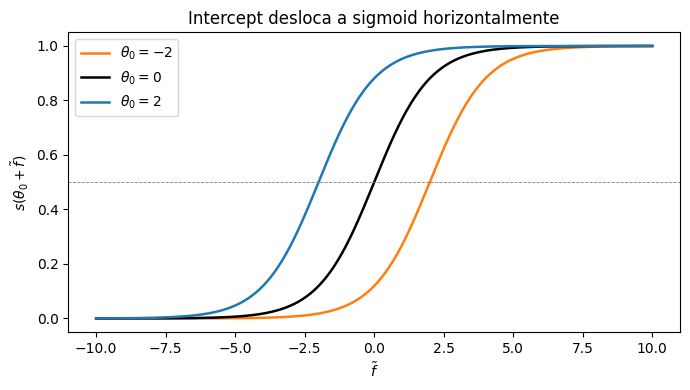

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
for theta0, color in [(-2, 'tab:orange'), (0, 'black'), (2, 'tab:blue')]:
    ax.plot(z, sigmoid(z + theta0), color=color, linewidth=1.8,
            label=fr'$\theta_0 = {theta0}$')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.6)
ax.set_xlabel(r'$\tilde f$'); ax.set_ylabel(r'$s(\theta_0 + \tilde f)$')
ax.set_title('Intercept desloca a sigmoid horizontalmente')
ax.legend(); plt.tight_layout(); plt.show()

### 3.2 Efeito da escala $\alpha$ --- inclinação e direção

Multiplicar o score por uma constante $\alpha$ controla a **inclinação** da transição (quanto maior $|\alpha|$, mais abrupta) e o **sinal** de $\alpha$ define a direção (positivo: cresce para a direita; negativo: decresce).

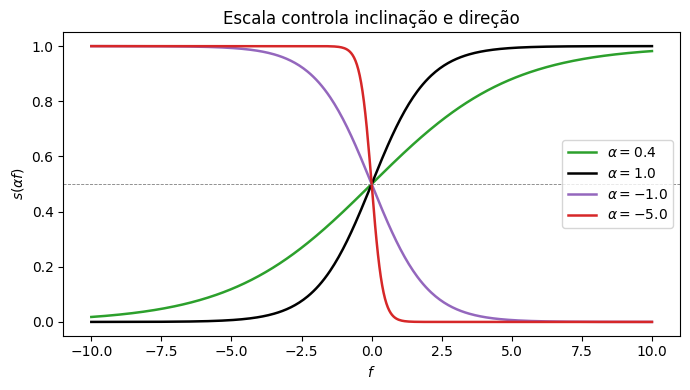

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for alpha, color in [(0.4, 'tab:green'), (1.0, 'black'),
                     (-1.0, 'tab:purple'), (-5.0, 'tab:red')]:
    ax.plot(z, sigmoid(alpha * z), color=color, linewidth=1.8,
            label=fr'$\alpha = {alpha}$')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.6)
ax.set_xlabel(r'$f$'); ax.set_ylabel(r'$s(\alpha f)$')
ax.set_title('Escala controla inclinação e direção')
ax.legend(); plt.tight_layout(); plt.show()

---
## 4. Espaço de hipóteses da regressão logística

Combinando a estrutura linear com a sigmoid, o **espaço de hipóteses** é o conjunto de todas as funções $\pi : \mathcal{X} \to [0, 1]$ da forma
$$\mathcal{H} = \left\{\pi : \mathcal{X} \to [0, 1] \;\middle|\; \pi(\mathbf{x} \mid \boldsymbol{\theta}) = s(\boldsymbol{\theta}^\top \mathbf{x}),\ \boldsymbol{\theta} \in \mathbb{R}^{p+1}\right\}.$$
O parâmetro $\boldsymbol{\theta} \in \mathbb{R}^{p+1}$ inclui o intercept; o $+1$ é por causa da coluna de $1$s adicionada à matriz de features (mesma convenção dos notebooks anteriores).

---
## 5. Logit e log-odds

A inversa da sigmoid é o **logit**:
$$s^{-1}(\pi) = \log\!\left(\frac{\pi}{1 - \pi}\right).$$
Como $\pi / (1 - \pi)$ é a **odd** (chance) do evento $y = 1$, o logit também é chamado de **log-odds**. Aplicando a inversa nos dois lados de $\pi(\mathbf{x}) = s(\boldsymbol{\theta}^\top \mathbf{x})$:
$$s^{-1}(\pi(\mathbf{x})) = \log\!\left(\frac{\pi(\mathbf{x})}{1 - \pi(\mathbf{x})}\right) = \boldsymbol{\theta}^\top \mathbf{x}.$$

Em outras palavras: as features atuam **linearmente nos log-odds**, controladas pelos coeficientes $\boldsymbol{\theta}$. Logits positivos correspondem a $\pi > 0{,}5$ e vice-versa. Por exemplo, se $\pi = 0{,}75$, então a odd é $3{:}1$ e o logit vale $\log(3) \approx 1{,}1$.

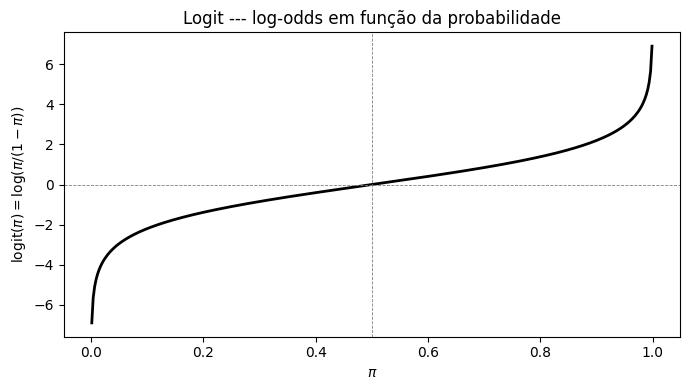

In [7]:
pi_grid = np.linspace(0.001, 0.999, 400)
logit = np.log(pi_grid / (1 - pi_grid))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pi_grid, logit, color='black', linewidth=2)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.6)
ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.6)
ax.set_xlabel(r'$\pi$')
ax.set_ylabel(r'$\mathrm{logit}(\pi) = \log(\pi / (1 - \pi))$')
ax.set_title('Logit --- log-odds em função da probabilidade')
plt.tight_layout(); plt.show()

---
## 6. Loss --- derivação da log-loss

Precisamos de uma loss adequada para o ERM. Olhamos para a **likelihood**: o produto, sobre todas as observações, da probabilidade que o modelo atribui ao rótulo observado.

- Para $y^{(i)} = 1$, a contribuição é $\pi(\mathbf{x}^{(i)} \mid \boldsymbol{\theta})$.
- Para $y^{(i)} = 0$, a contribuição é $1 - \pi(\mathbf{x}^{(i)} \mid \boldsymbol{\theta})$.

Combinando os dois casos com expoentes (apenas um dos fatores fica "ativo" em cada $i$):
$$\mathcal{L}(\boldsymbol{\theta}) = \prod_{i=1}^{n} \pi(\mathbf{x}^{(i)} \mid \boldsymbol{\theta})^{\,y^{(i)}}\, \left(1 - \pi(\mathbf{x}^{(i)} \mid \boldsymbol{\theta})\right)^{\,1 - y^{(i)}}.$$

Tomando $-\log$ (transforma produto em soma e maximização em minimização) e dividindo por $n$, chegamos à **log-loss** (também chamada de Bernoulli, binomial ou cross-entropy loss):
$$L(y, \pi(\mathbf{x})) = -y \log(\pi(\mathbf{x})) - (1 - y) \log(1 - \pi(\mathbf{x})).$$

Essa é a loss canônica da regressão logística e aparece em muitos outros classificadores (redes neurais, boosting).

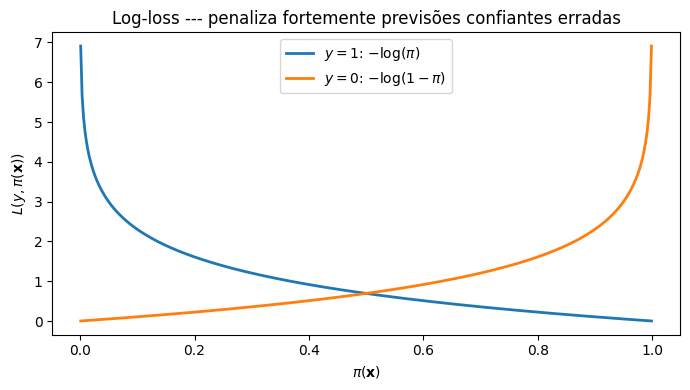

In [8]:
pi_grid = np.linspace(0.001, 0.999, 400)
loss_y1 = -np.log(pi_grid)
loss_y0 = -np.log(1 - pi_grid)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pi_grid, loss_y1, color='tab:blue', linewidth=2,
        label=r'$y = 1$: $-\log(\pi)$')
ax.plot(pi_grid, loss_y0, color='tab:orange', linewidth=2,
        label=r'$y = 0$: $-\log(1 - \pi)$')
ax.set_xlabel(r'$\pi(\mathbf{x})$'); ax.set_ylabel(r'$L(y, \pi(\mathbf{x}))$')
ax.set_title('Log-loss --- penaliza fortemente previsões confiantes erradas')
ax.legend(); plt.tight_layout(); plt.show()

A log-loss tem uma propriedade importante: ela **explode** conforme a probabilidade prevista para o rótulo correto se aproxima de zero. Em outras palavras, errar com confiança é catastroficamente caro --- exatamente o que queremos para um classificador probabilístico bem calibrado.

---
## 7. Otimização

Diferentemente da regressão linear (loss L2 + modelo linear), aqui **não existe solução analítica**. A boa notícia: a log-loss é **convexa** em $\boldsymbol{\theta}$, então minimização numérica funciona bem. Métodos clássicos: Newton-Raphson, L-BFGS e gradiente descendente.

(Atenção: se os dados forem **linearmente separáveis**, o problema fica ilimitado --- os coeficientes divergem para $\pm \infty$. A saída usual é regularização. Não exploramos esse cenário aqui.)

Observação: tentar minimizar L2 em $\pi(\mathbf{x}) = s(\boldsymbol{\theta}^\top \mathbf{x})$ não é uma opção. Como a sigmoid não é linear, a L2 composta deixa de ser convexa --- aparecem mínimos locais.

### 7.1 Gradiente da log-loss --- derivação passo a passo

Vamos derivar $\nabla_{\boldsymbol{\theta}}\, \mathcal{R}_{\text{emp}}(\boldsymbol{\theta})$. Para uma única observação $(\mathbf{x}^{(i)}, y^{(i)})$, a contribuição da log-loss é:
$$L^{(i)} = -y^{(i)} \log(\pi^{(i)}) - (1 - y^{(i)}) \log(1 - \pi^{(i)}),$$
onde $\pi^{(i)} = s(z^{(i)})$ e $z^{(i)} = \boldsymbol{\theta}^\top \mathbf{x}^{(i)}$.

A loss depende de $\theta_j$ por uma cadeia de três funções: $\theta_j \to z^{(i)} \to \pi^{(i)} \to L^{(i)}$. Aplicamos a regra da cadeia:
$$\frac{\partial L^{(i)}}{\partial \theta_j} \;=\; \underbrace{\frac{\partial L^{(i)}}{\partial \pi^{(i)}}}_{(a)} \cdot \underbrace{\frac{\partial \pi^{(i)}}{\partial z^{(i)}}}_{(b)} \cdot \underbrace{\frac{\partial z^{(i)}}{\partial \theta_j}}_{(c)}.$$

**(a) Derivada da loss em relação a $\pi$.** Derivando $-y \log(\pi) - (1-y)\log(1-\pi)$ em $\pi$:
$$\frac{\partial L^{(i)}}{\partial \pi^{(i)}} = -\frac{y^{(i)}}{\pi^{(i)}} + \frac{1 - y^{(i)}}{1 - \pi^{(i)}}.$$
Colocando sobre o denominador comum $\pi^{(i)}(1 - \pi^{(i)})$ e simplificando o numerador (note que $-y(1-\pi) + (1-y)\pi = \pi - y$):
$$\frac{\partial L^{(i)}}{\partial \pi^{(i)}} = \frac{\pi^{(i)} - y^{(i)}}{\pi^{(i)}(1 - \pi^{(i)})}.$$

**(b) Derivada da sigmoid.** Usando $s(z) = (1 + e^{-z})^{-1}$ e a regra do quociente:
$$s'(z) = \frac{e^{-z}}{(1 + e^{-z})^2} = \underbrace{\frac{1}{1 + e^{-z}}}_{= s(z)} \cdot \underbrace{\frac{e^{-z}}{1 + e^{-z}}}_{= 1 - s(z)} = s(z)\,(1 - s(z)).$$
Aplicado em $z^{(i)}$, isso vira $\pi^{(i)}(1 - \pi^{(i)})$.

**(c) Derivada do score linear.** Como $z^{(i)} = \theta_0 + \theta_1 x_1^{(i)} + \cdots + \theta_p x_p^{(i)}$, derivar em $\theta_j$ deixa apenas o termo onde $\theta_j$ aparece:
$$\frac{\partial z^{(i)}}{\partial \theta_j} = x_j^{(i)},$$
com a convenção $x_0^{(i)} \equiv 1$ para o intercept.

**Combinando os três fatores:**
$$\frac{\partial L^{(i)}}{\partial \theta_j} = \frac{\pi^{(i)} - y^{(i)}}{\pi^{(i)}(1 - \pi^{(i)})} \cdot \pi^{(i)}(1 - \pi^{(i)}) \cdot x_j^{(i)} = \left(\pi^{(i)} - y^{(i)}\right)\, x_j^{(i)}.$$

A elegância está no cancelamento: o fator $\pi(1-\pi)$ aparece **uma vez no denominador** (vindo da derivada da log-loss) e **uma vez no numerador** (vindo da derivada da sigmoid), e os dois se cancelam. É essa harmonia algébrica que faz da log-loss a loss "natural" para a sigmoid --- com qualquer outra loss, sobraria uma curvatura $\pi(1-\pi)$ atrapalhando o gradiente.

**Somando sobre as $n$ observações** (e dividindo por $n$, já que usamos a loss média):
$$\frac{\partial \mathcal{R}_{\text{emp}}}{\partial \theta_j} = \frac{1}{n}\sum_{i=1}^n \left(\pi^{(i)} - y^{(i)}\right)\, x_j^{(i)}.$$

Empilhando as derivadas $\partial \mathcal{R}_{\text{emp}} / \partial \theta_j$ em um vetor para $j = 0, 1, \ldots, p$ e reconhecendo o produto matricial $\mathbf{X}^\top \mathbf{v} = \sum_i v_i\, \mathbf{x}^{(i)}$:
$$\boxed{\;\nabla_{\boldsymbol{\theta}}\, \mathcal{R}_{\text{emp}}(\boldsymbol{\theta}) = \frac{1}{n}\, \mathbf{X}^\top (\boldsymbol{\pi} - \mathbf{y}),\;}$$
onde $\boldsymbol{\pi} = s(\mathbf{X}\boldsymbol{\theta}) \in [0, 1]^n$ é o vetor de probabilidades previstas.

Note como o gradiente é **estruturalmente o mesmo** da regressão linear: lá tínhamos $\nabla_{\boldsymbol{\theta}}\, \mathcal{R}_{\text{emp}} = -\tfrac{2}{n}\mathbf{X}^\top(\mathbf{y} - \mathbf{X}\boldsymbol{\theta})$; aqui só trocamos o resíduo $(\mathbf{y} - \mathbf{X}\boldsymbol{\theta})$ pelo "resíduo probabilístico" $(\boldsymbol{\pi} - \mathbf{y})$ (e perdemos o fator $-2$ porque a derivada da log-loss já vem com sinal certo). Isso permite reaproveitar quase todo o código do notebook 02 --- só muda a fórmula do gradiente.

---
## 8. Implementação

### 8.1 Dataset sintético com parâmetros conhecidos

Para verificar que a implementação está correta, geramos dados onde sabemos os $\boldsymbol{\theta}$ verdadeiros (mesmo padrão dos notebooks 01 e 02). Cenário: prever se um aluno **passa em uma prova** ($y = 1$) ou não ($y = 0$) a partir de duas features:

- `horas_estudo`: horas dedicadas ao estudo na semana ($\sim \text{Uniforme}(0, 10)$);
- `horas_sono`: média de horas de sono por noite ($\sim \text{Uniforme}(4, 9)$).

Modelo verdadeiro:
$$p(\text{passa} = 1 \mid \mathbf{x}) = s(-6 + 0{,}9 \cdot \text{horas\_estudo} + 0{,}5 \cdot \text{horas\_sono}).$$

In [20]:
np.random.seed(42)
n = 300

horas_estudo = np.random.uniform(0, 10, n)
horas_sono = np.random.uniform(4, 9, n)

TRUE_INTERCEPT = -6.0
TRUE_BETA_ESTUDO = 0.9
TRUE_BETA_SONO = 0.5

logit_true = (TRUE_INTERCEPT
              + TRUE_BETA_ESTUDO * horas_estudo
              + TRUE_BETA_SONO * horas_sono)
p_true = sigmoid(logit_true)
passa = (np.random.uniform(size=n) < p_true).astype(int)

alunos = pd.DataFrame({
    'horas_estudo': horas_estudo,
    'horas_sono':   horas_sono,
    'passa':        passa,
})
print(f'n = {n}, proporção de aprovados: {alunos["passa"].mean():.3f}')
alunos.head()

n = 300, proporção de aprovados: 0.703


,horas_estudo,horas_sono,passa
0,3.745401,4.258409,1
1,9.507143,6.656773,1
2,7.319939,6.703176,1
3,5.986585,7.187150,1
4,1.560186,7.630457,1


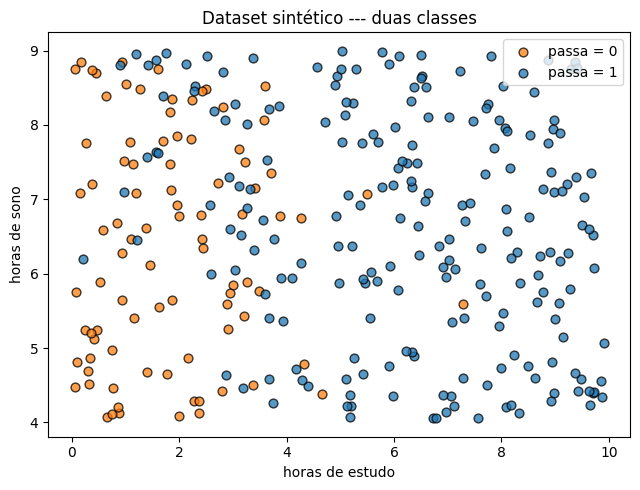

In [21]:
# Visualização do dataset
fig, ax = plt.subplots(figsize=(6.5, 5))
for cls, color, label in [(0, 'tab:orange', 'passa = 0'),
                          (1, 'tab:blue',   'passa = 1')]:
    sub = alunos[alunos['passa'] == cls]
    ax.scatter(sub['horas_estudo'], sub['horas_sono'], c=color,
               edgecolors='black', s=40, alpha=0.75, label=label)
ax.set_xlabel('horas de estudo'); ax.set_ylabel('horas de sono')
ax.set_title('Dataset sintético --- duas classes')
ax.legend(); plt.tight_layout(); plt.show()

### 8.2 Gradiente descendente para regressão logística

A função abaixo é praticamente a mesma do notebook 02, com duas mudanças:
1. usamos a sigmoid para gerar previsões $\boldsymbol{\pi} = s(\mathbf{X}\boldsymbol{\theta})$;
2. o gradiente é $\mathbf{X}^\top(\boldsymbol{\pi} - \mathbf{y}) / n$ em vez de $-\tfrac{2}{n}\mathbf{X}^\top(\mathbf{y} - \mathbf{X}\boldsymbol{\theta})$.
3. log-loss média: $-\frac{1}{n}\sum_{i=1}^{n}\left[y^{(i)}\log(p^{(i)}) + (1-y^{(i)})\log(1-p^{(i)}) \right]$
4. Usamos $\texttt{np.clip}(p,\ \varepsilon,\ 1-\varepsilon)$ para evitar problemas numéricos quando p fica extremamente próximo de 0 ou 1, impedindo o cálculo de $\log(0)$

A loss reportada é a log-loss média.

In [41]:
def log_loss(y, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


def gd_logistic(X, y, learning_rate, n_iterations, theta_init=None):
    n_samples, n_features = X.shape
    theta = np.zeros(n_features) if theta_init is None else theta_init.copy()
    loss_history, theta_history = [], [theta.copy()]
    for _ in range(n_iterations):
        p = sigmoid(X @ theta)
        loss_history.append(log_loss(y, p))
        gradient = (X.T @ (p - y)) / n_samples
        theta = theta - learning_rate * gradient
        theta_history.append(theta.copy())
    return theta, loss_history, np.array(theta_history)

Como no notebook 02, normalizamos as features (z-score) antes de rodar o GD para que tenham escalas comparáveis. Isso melhora muito a velocidade de convergência.

In [42]:
X_raw = alunos[['horas_estudo', 'horas_sono']].values
y = alunos['passa'].values.astype(float)

X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X_norm = (X_raw - X_mean) / X_std
X_gd = np.column_stack([np.ones(n), X_norm])

theta_gd, losses, _ = gd_logistic(X_gd, y, learning_rate=0.5, n_iterations=2000)
print(f'log-loss inicial: {losses[0]:.4f}')
print(f'log-loss final:   {losses[-1]:.4f}')

log-loss inicial: 0.6931
log-loss final:   0.2804


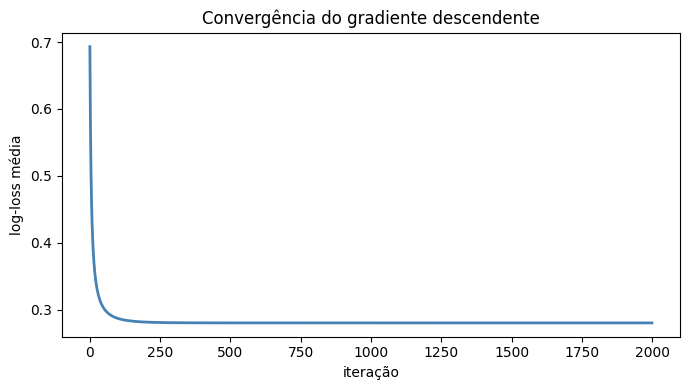

In [43]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(losses, color='steelblue', linewidth=2)
ax.set_xlabel('iteração'); ax.set_ylabel('log-loss média')
ax.set_title('Convergência do gradiente descendente')
plt.tight_layout(); plt.show()

### 8.3 Voltando do espaço normalizado para o espaço original

Os parâmetros aprendidos pelo GD vivem no **espaço normalizado** --- ou seja, $\boldsymbol{\theta}^{\text{norm}}$ são os coeficientes corretos para predizer a partir de $\tilde x_j = (x_j - \mu_j) / \sigma_j$, e não a partir de $x_j$ direto. Para comparar com os $\boldsymbol{\theta}$ verdadeiros do gerador (que descrevem o efeito de cada $x_j$ na escala original), precisamos **converter de volta**.

Vamos derivar a fórmula de conversão expandindo o score linear no espaço normalizado:
$$
\boldsymbol{\theta}^{\text{norm}\top}\!\tilde{\mathbf{x}}
\;=\; \theta_0^{\text{norm}} + \sum_{j=1}^p \theta_j^{\text{norm}} \cdot \frac{x_j - \mu_j}{\sigma_j}
\;=\; \theta_0^{\text{norm}} + \sum_{j=1}^p \frac{\theta_j^{\text{norm}}}{\sigma_j} x_j - \sum_{j=1}^p \frac{\theta_j^{\text{norm}}\, \mu_j}{\sigma_j}.
$$

Reagrupando termos constantes (as duas parcelas que não dependem de $\mathbf{x}$) e termos lineares em $x_j$:
$$
\boldsymbol{\theta}^{\text{norm}\top}\!\tilde{\mathbf{x}}
\;=\; \underbrace{\left(\theta_0^{\text{norm}} - \sum_{j=1}^p \frac{\theta_j^{\text{norm}}\, \mu_j}{\sigma_j}\right)}_{\theta_0^{\text{orig}}}
\;+\; \sum_{j=1}^p \underbrace{\frac{\theta_j^{\text{norm}}}{\sigma_j}}_{\theta_j^{\text{orig}}}\, x_j.
$$

Lendo termo a termo, para que as previsões fiquem **idênticas** nas duas escalas, basta definir:
$$
\boxed{\;\theta_j^{\text{orig}} = \frac{\theta_j^{\text{norm}}}{\sigma_j}, \qquad
\theta_0^{\text{orig}} = \theta_0^{\text{norm}} - \sum_{j=1}^p \theta_j^{\text{norm}}\, \frac{\mu_j}{\sigma_j}.\;}
$$

A intuição é direta:
- **Coeficientes das features**: se uma feature foi *encolhida* dividindo por $\sigma_j$, o coeficiente que ela merece na escala original tem que ser correspondentemente *encolhido* também --- daí a divisão por $\sigma_j$.
- **Intercept**: a normalização também subtrai $\mu_j$ de cada feature, e essa subtração injeta uma constante $-\theta_j^{\text{norm}} \mu_j / \sigma_j$ no score. Para reproduzir o mesmo score na escala original, essa constante precisa ser absorvida pelo intercept, e por isso a soma aparece com sinal negativo.

Importante: estamos apenas reescrevendo o **mesmo score linear** em duas parametrizações diferentes. As probabilidades previstas $\pi(\mathbf{x}) = s(\boldsymbol{\theta}^\top \mathbf{x})$ são exatamente iguais nas duas escalas --- a transformação não muda o modelo, só a forma de escrever os coeficientes.

In [44]:
theta_gd_orig = np.zeros(3)
theta_gd_orig[1:] = theta_gd[1:] / X_std
theta_gd_orig[0] = theta_gd[0] - np.sum(theta_gd[1:] * X_mean / X_std)

print(f'intercept:    {theta_gd_orig[0]:+.4f}  (verdadeiro: {TRUE_INTERCEPT:+.4f})')
print(f'horas_estudo: {theta_gd_orig[1]:+.4f}  (verdadeiro: {TRUE_BETA_ESTUDO:+.4f})')
print(f'horas_sono:   {theta_gd_orig[2]:+.4f}  (verdadeiro: {TRUE_BETA_SONO:+.4f})')

intercept:    -6.0603  (verdadeiro: -6.0000)
horas_estudo: +1.1039  (verdadeiro: +0.9000)
horas_sono:   +0.4412  (verdadeiro: +0.5000)


In [45]:
# Verificação: as probabilidades previstas são iguais nas duas parametrizações?
p_norm = sigmoid(X_gd @ theta_gd)                                         # espaço normalizado
p_orig = sigmoid(np.column_stack([np.ones(n), X_raw]) @ theta_gd_orig)    # espaço original
max_diff = np.max(np.abs(p_norm - p_orig))
print(f'diferença máxima entre as previsões nas duas escalas: {max_diff:.2e}')
print('(deve ser ~0 --- só reescrevemos o mesmo modelo)')

diferença máxima entre as previsões nas duas escalas: 5.55e-16
(deve ser ~0 --- só reescrevemos o mesmo modelo)


Os valores estimados ficam próximos dos verdadeiros, mas não exatos --- o ruído de amostragem no Bernoulli impede a recuperação perfeita. E a checagem acima confirma que a conversão preserva o modelo: as previsões são bit-a-bit iguais nas duas escalas.

---
## 9. Comparação com bibliotecas

### 9.1 scikit-learn

A `LogisticRegression` do `sklearn` aplica regularização L2 por padrão (controlada por `C`). Para reproduzir a versão sem regularização --- que é o que nosso GD faz --- usamos `penalty=None`. A biblioteca trabalha com os dados na escala original.

In [46]:
from sklearn.linear_model import LogisticRegression

clf_sk = LogisticRegression(penalty=None, solver='lbfgs', max_iter=2000)
clf_sk.fit(X_raw, y)

print(f'intercept:    {clf_sk.intercept_[0]:+.4f}')
print(f'horas_estudo: {clf_sk.coef_[0, 0]:+.4f}')
print(f'horas_sono:   {clf_sk.coef_[0, 1]:+.4f}')
print(f'acurácia (treino): {clf_sk.score(X_raw, y):.4f}')

intercept:    -6.0607
horas_estudo: +1.1041
horas_sono:   +0.4412
acurácia (treino): 0.8733


/Users/paulomann/miniconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### 9.2 statsmodels

A classe `Logit` do `statsmodels` produz um relatório no estilo de inferência estatística, com erros padrão, p-values, log-likelihood e pseudo-$R^2$. Como em OLS, é preciso adicionar manualmente a coluna de $1$s para o intercept.

In [48]:
import statsmodels.api as sm

X_sm = sm.add_constant(X_raw)
result_sm = sm.Logit(y, X_sm).fit(disp=False)
print(result_sm.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  300
Model:                          Logit   Df Residuals:                      297
Method:                           MLE   Df Model:                            2
Date:                Sun, 10 May 2026   Pseudo R-squ.:                  0.5388
Time:                        20:02:04   Log-Likelihood:                -84.127
converged:                       True   LL-Null:                       -182.40
Covariance Type:            nonrobust   LLR p-value:                 2.083e-43
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.0603      1.199     -5.054      0.000      -8.410      -3.710
x1             1.1039      0.140      7.869      0.000       0.829       1.379
x2             0.4412      0.142      3.109      0.0

### 9.3 Tabela comparativa

As três abordagens (gradiente descendente from scratch, scikit-learn, statsmodels) resolvem o mesmo problema de otimização e devem coincidir até a precisão numérica.

In [49]:
comparison = pd.DataFrame({
    'verdadeiro':      [TRUE_INTERCEPT, TRUE_BETA_ESTUDO, TRUE_BETA_SONO],
    'GD from scratch': theta_gd_orig,
    'sklearn':         [clf_sk.intercept_[0], clf_sk.coef_[0, 0], clf_sk.coef_[0, 1]],
    'statsmodels':     result_sm.params,
}, index=['intercept', 'horas_estudo', 'horas_sono'])
comparison.round(4)

,verdadeiro,GD from scratch,sklearn,statsmodels
intercept,-6.0,-6.0603,-6.0607,-6.0603
horas_estudo,0.9,1.1039,1.1041,1.1039
horas_sono,0.5,0.4412,0.4412,0.4412


---
## 10. Fronteira de decisão em 2D

A regressão logística é um **classificador linear**: a fronteira de decisão (onde $\pi(\mathbf{x} \mid \boldsymbol{\theta}) = 0{,}5$) corresponde a $\boldsymbol{\theta}^\top \mathbf{x} = 0$, que é uma reta no plano $(x_1, x_2)$. Vamos visualizar essa reta junto com a probabilidade prevista em cada ponto da grade.

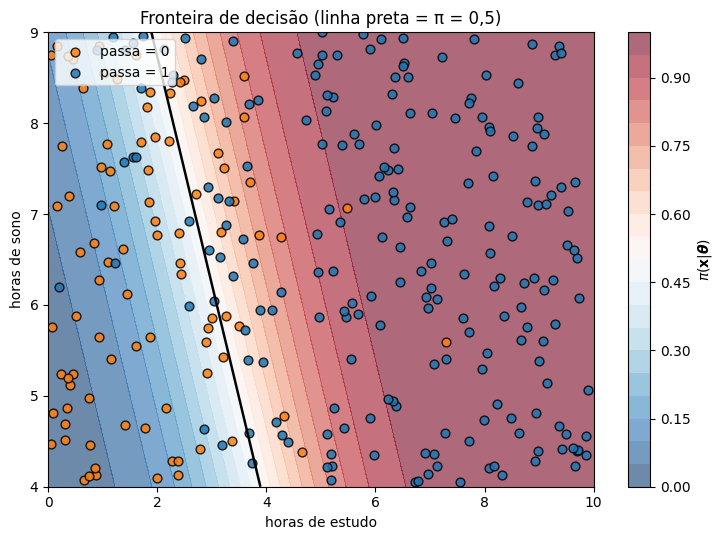

In [19]:
xx, yy = np.meshgrid(
    np.linspace(0, 10, 200),
    np.linspace(4, 9, 200),
)
grid = np.column_stack([xx.ravel(), yy.ravel()])
prob_grid = clf_sk.predict_proba(grid)[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7.5, 5.5))
contour = ax.contourf(xx, yy, prob_grid, levels=20, cmap='RdBu_r', alpha=0.6)
plt.colorbar(contour, ax=ax, label=r'$\pi(\mathbf{x}|\boldsymbol{\theta})$')
ax.contour(xx, yy, prob_grid, levels=[0.5], colors='black', linewidths=1.8)

for cls, color, label in [(0, 'tab:orange', 'passa = 0'),
                          (1, 'tab:blue',   'passa = 1')]:
    sub = alunos[alunos['passa'] == cls]
    ax.scatter(sub['horas_estudo'], sub['horas_sono'], c=color,
               edgecolors='black', s=40, alpha=0.85, label=label)
ax.set_xlabel('horas de estudo'); ax.set_ylabel('horas de sono')
ax.set_title('Fronteira de decisão (linha preta = π = 0,5)')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

A reta preta separa os dois semiespaços: à direita dela o modelo prevê $\hat y = 1$ (passa); à esquerda, $\hat y = 0$. Como o classificador é probabilístico, a coloração em gradiente mostra também a **confiança** da previsão --- pontos longe da fronteira recebem $\pi \to 0$ ou $\pi \to 1$, enquanto pontos sobre a reta ficam em $\pi = 0{,}5$ (caso indeciso).

---
## 11. Resumo

| Aspecto | Regressão linear (notebooks 01--02) | Regressão logística (este notebook) |
|---|---|---|
| Target $y$ | contínuo | binário, $\{0, 1\}$ |
| Hipótese | $f(\mathbf{x}) = \boldsymbol{\theta}^\top \mathbf{x}$ | $\pi(\mathbf{x}) = s(\boldsymbol{\theta}^\top \mathbf{x})$ |
| Loss | L2 (erro quadrático) | log-loss / cross-entropy |
| Convexidade da loss | sim | sim |
| Solução analítica | sim (OLS) | não |
| Otimizador típico | OLS ou GD | GD, L-BFGS, Newton-Raphson |
| Saída interpretável | resposta esperada $\hat y$ | probabilidade $\pi$ ou classe via threshold |
| Fronteira de decisão | --- | hiperplano linear |

O ingrediente novo é a **sigmoid** (que esmaga o score linear para $[0, 1]$) combinada com a **log-loss** (derivada da likelihood Bernoulli). A estrutura do gradiente descendente fica intacta --- só trocamos a fórmula do gradiente.

Próximos passos típicos: (i) escolha de threshold de classificação (também tratada na lista 3 de exercícios); (ii) regularização L1/L2; (iii) generalização para múltiplas classes via softmax (também presente na lista 3).